In [50]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150
COLORS = {'Toronto': '#2196F3', 'Vancouver': '#FF5722'}

df = pd.read_parquet("../data/merged_crime_data.parquet")
print("Loaded:", df.shape)
print(df['crime_group'].value_counts())

Loaded: (696694, 10)
crime_group
Property Crime     400644
Violent Crime      234800
Property Damage     50049
Other               11201
Name: count, dtype: int64


In [51]:
# Model 1: K-Means Clustering
# Create feature matrix for each neighbourhood
neighbourhood_features = (
    df.groupby(['city', 'neighbourhood'])
    .agg(
        total_crimes = ('crime_type', 'count'),
        violent_pct = ('crime_group', lambda x: (x == 'Violent Crime').mean() * 100),
        property_pct = ('crime_group', lambda x: (x == 'Property Crime').mean() * 100),
        avg_hour = ('hour', 'mean'),
        night_pct = ('hour', lambda x: (x <= 6).mean() * 100),
    )
    .reset_index()
)

print("Features shape:", neighbourhood_features.shape)
print(neighbourhood_features.head())

Features shape: (182, 7)
      city                       neighbourhood  ...   avg_hour  night_pct
0  Toronto               Agincourt North (129)  ...  13.124220  21.205821
1  Toronto  Agincourt South-Malvern West (128)  ...  11.938897  28.666201
2  Toronto                      Alderwood (20)  ...  11.913284  30.442804
3  Toronto                          Annex (95)  ...  12.038077  27.929014
4  Toronto                      Avondale (153)  ...  12.031142  26.758939

[5 rows x 7 columns]


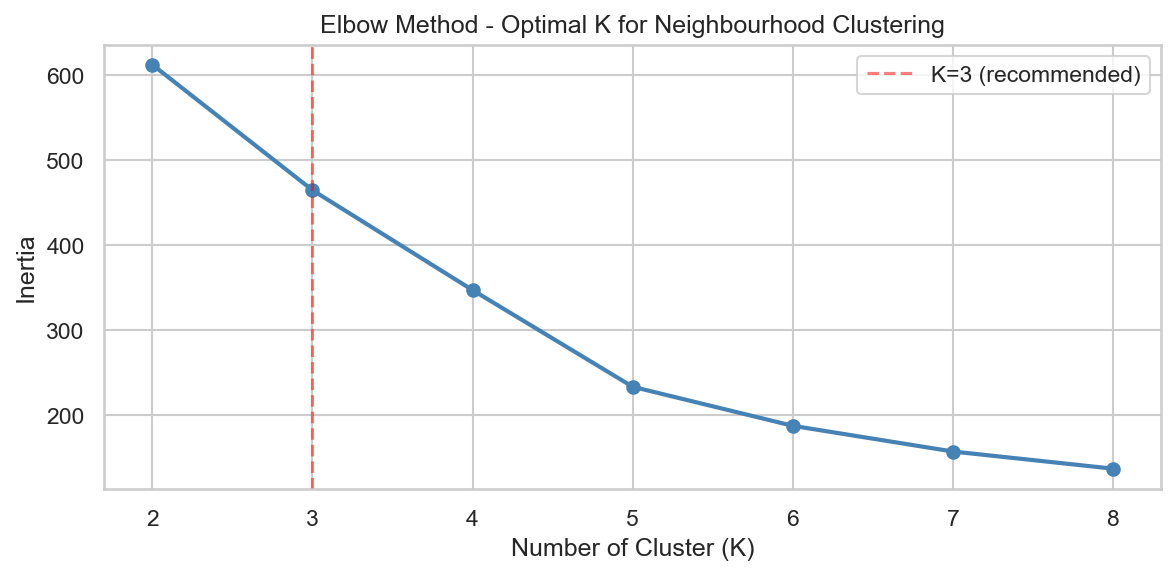

In [52]:
# Elbow method (choose cluster number)
X = neighbourhood_features[['total_crimes', 'violent_pct', 'property_pct', 'avg_hour', 'night_pct']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertias = []
K_range = range(2,9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init = 10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(K_range, inertias, marker='o', color = 'steelblue', linewidth = 2)
ax.set_xlabel("Number of Cluster (K)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Method - Optimal K for Neighbourhood Clustering")
ax.axvline(x=3, color='red', linestyle = '--', alpha=0.5, label='K=3 (recommended)')
ax.legend()
plt.tight_layout()
plt.savefig("../output/figures/elbow_method.png", dpi = 150, bbox_inches = 'tight')
plt.show()

In [53]:
# Fit K-Means with K=3
km = KMeans(n_clusters=3, random_state=42, n_init=10)
neighbourhood_features['cluster'] = km.fit_predict(X_scaled)

# Label cluster based on risk level using total crimes
cluster_risk = (
    neighbourhood_features.groupby('cluster')['total_crimes']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
cluster_risk['risk_label'] = ['High Risk', 'Medium Risk', 'Low Risk']
risk_map = dict(zip(cluster_risk['cluster'], cluster_risk['risk_label']))
neighbourhood_features['risk_level'] = neighbourhood_features['cluster'].map(risk_map)

print("Cluster distribution:")
print(neighbourhood_features['risk_level'].value_counts())
print("\nCluster summary:")
print(neighbourhood_features.groupby('risk_level')[
    ['total_crimes', 'violent_pct', 'property_pct', 'avg_hour', 'night_pct']
].mean().round(2))

Cluster distribution:
risk_level
Low Risk       146
High Risk       34
Medium Risk      2
Name: count, dtype: int64

Cluster summary:
             total_crimes  violent_pct  property_pct  avg_hour  night_pct
risk_level                                                               
High Risk        10636.56        13.66         73.94     12.65      24.22
Low Risk          2250.77        60.39         39.61     12.64      24.74
Medium Risk       3219.00        52.22         34.76      8.73      49.33


Toronto: {'Medium Risk': 71, 'High Risk': 51, 'Low Risk': 36}
Vancouver: {'Medium Risk': 22, 'High Risk': 1, 'Low Risk': 1}


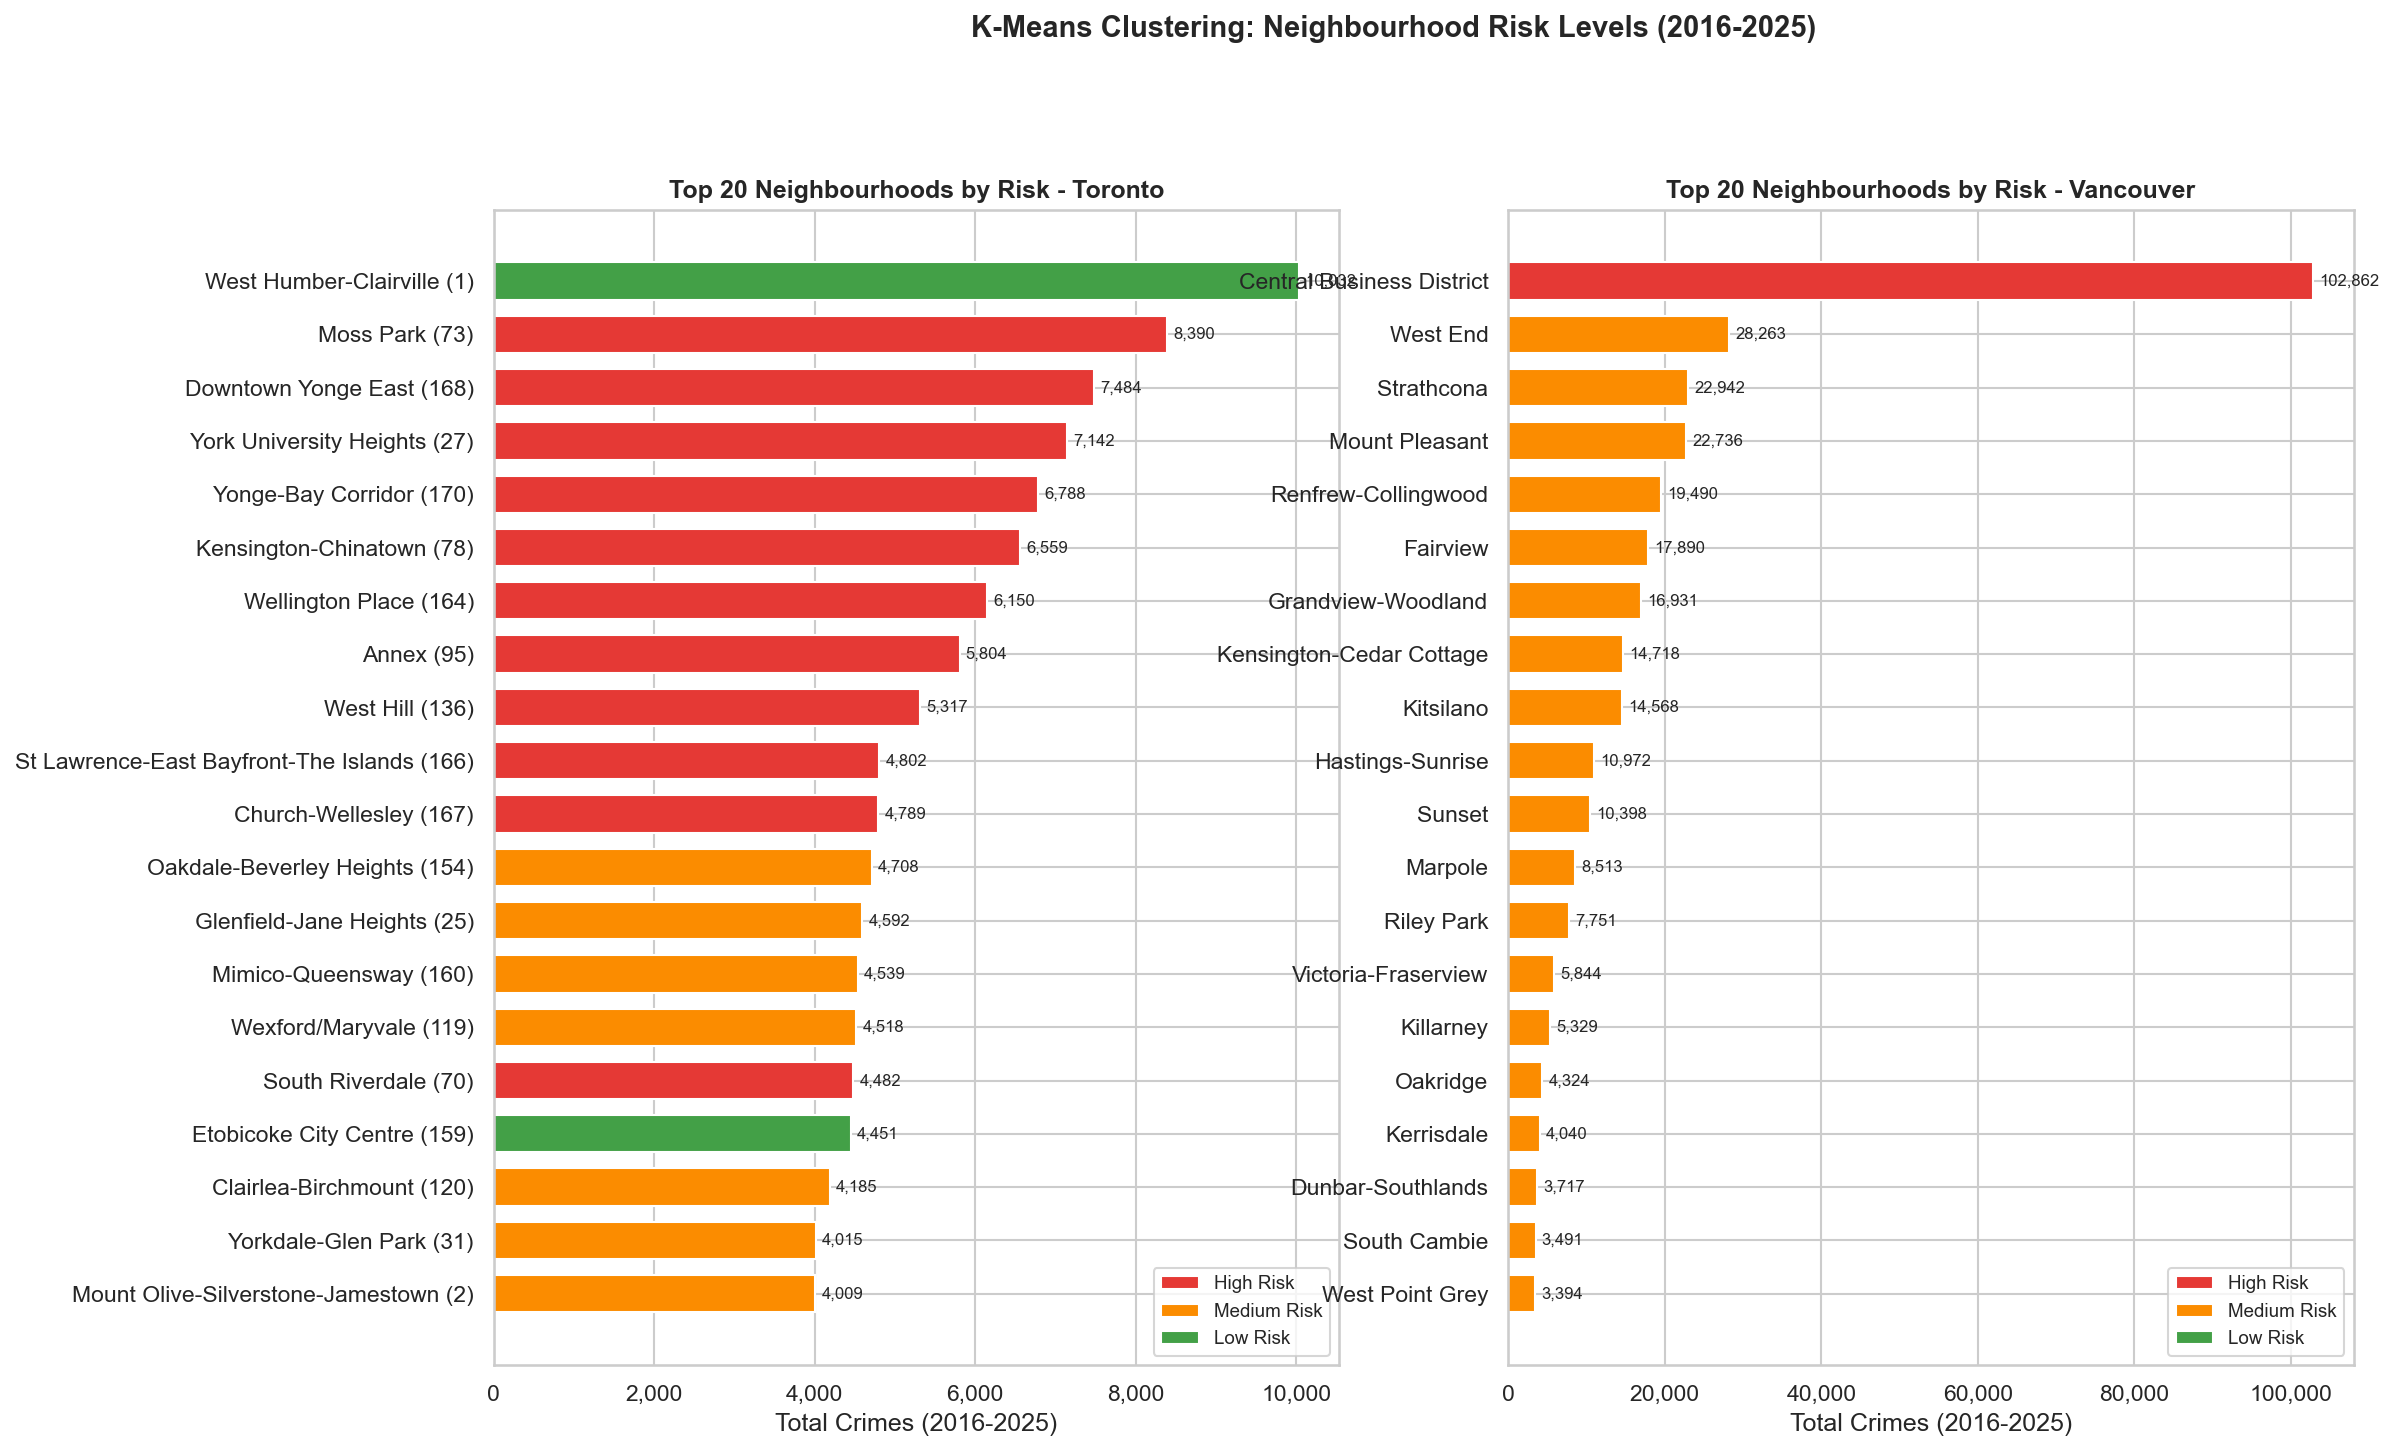

In [54]:
# Visualize clusters
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch

# Individual city cluster
def cluster_city(city_data, n_clusters=3):
    X = city_data[['total_crimes', 'violent_pct', 'property_pct', 'avg_hour', 'night_pct']]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    km = KMeans(n_clusters=n_clusters, random_state = 42, n_init = 10)
    city_data = city_data.copy()
    city_data['cluster'] = km.fit_predict(X_scaled)
    cluster_rank = (
        city_data.groupby('cluster')['total_crimes']
        .mean().sort_values(ascending=False).reset_index()
    )
    risk_map = dict(zip(cluster_rank['cluster'],['High Risk', 'Medium Risk', 'Low Risk']))
    city_data['risk_level'] = city_data['cluster'].map(risk_map)
    return city_data

tor_clustered = cluster_city(neighbourhood_features[neighbourhood_features['city'] == 'Toronto'])
van_clustered = cluster_city(neighbourhood_features[neighbourhood_features['city'] == 'Vancouver'])

print("Toronto:", tor_clustered['risk_level'].value_counts().to_dict())
print("Vancouver:", van_clustered['risk_level'].value_counts().to_dict())

# Visualize
fig, axes = plt.subplots(1,2, figsize=(16,10))

risk_colors = {'High Risk': '#E53935', 'Medium Risk': '#FB8C00', 'Low Risk': '#43A047'}
from matplotlib.patches import Patch

for ax, city, data in zip(axes, ['Toronto', 'Vancouver'], [tor_clustered, van_clustered]):
    city_data = data.nlargest(20, 'total_crimes').sort_values('total_crimes', ascending = True)
    colors = [risk_colors[r] for r in city_data['risk_level']]
    bars = ax.barh(city_data['neighbourhood'], city_data['total_crimes'],
                   color=colors, edgecolor='white', height=0.7)
    ax.bar_label(bars, fmt='{:,.0f}', padding =3, fontsize= 8)
    legend_elements = [Patch(facecolor=c, label = l) for l, c in risk_colors.items()]
    ax.legend(handles = legend_elements, loc = 'lower right', fontsize=9)
    ax.set_title(f"Top 20 Neighbourhoods by Risk - {city}", fontweight = 'bold')
    ax.set_xlabel("Total Crimes (2016-2025)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    
plt.suptitle("K-Means Clustering: Neighbourhood Risk Levels (2016-2025)",
             fontsize = 14, fontweight='bold', y=1.01)
plt.tight_layout
plt.savefig("../output/figures/neighbourhood_clusters.png", dpi=150, bbox_inches='tight')
plt.show()

In [55]:
# Model 2: Random Forest Classification
# Prepare features
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Keep 2 main classes
df_model = df[df['crime_group'].isin(['Property Crime', 'Violent Crime'])].copy()

#Encode
le_city = LabelEncoder()
le_neighbourhood = LabelEncoder()
le_month = LabelEncoder()

df_model['city_enc'] = le_city.fit_transform(df_model['city'])
df_model['month_enc'] = le_month.fit_transform(df_model['month'].astype(str))
df_model['neigh_enc'] = le_neighbourhood.fit_transform(df_model['neighbourhood'])

# Only use crime_group has data
valid_groups = df_model['crime_group'].value_counts()
valid_groups = valid_groups[valid_groups > 1000].index
df_model = df_model[df_model['crime_group'].isin(valid_groups)]

X = df_model[['city_enc', 'hour', 'month_enc', 'neigh_enc']]
y = df_model['crime_group'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Classes:", y.value_counts().to_dict())
print("Train:", X_train.shape, "| Test:", X_test.shape)


Classes: {'Property Crime': 400644, 'Violent Crime': 234800}
Train: (508355, 4) | Test: (127089, 4)


In [56]:
# Train & Evaluate
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\nTraining...")
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))


Training...

=== Classification Report ===
                precision    recall  f1-score   support

Property Crime       0.99      0.62      0.76     80129
 Violent Crime       0.60      0.99      0.75     46960

      accuracy                           0.75    127089
     macro avg       0.80      0.80      0.75    127089
  weighted avg       0.85      0.75      0.76    127089



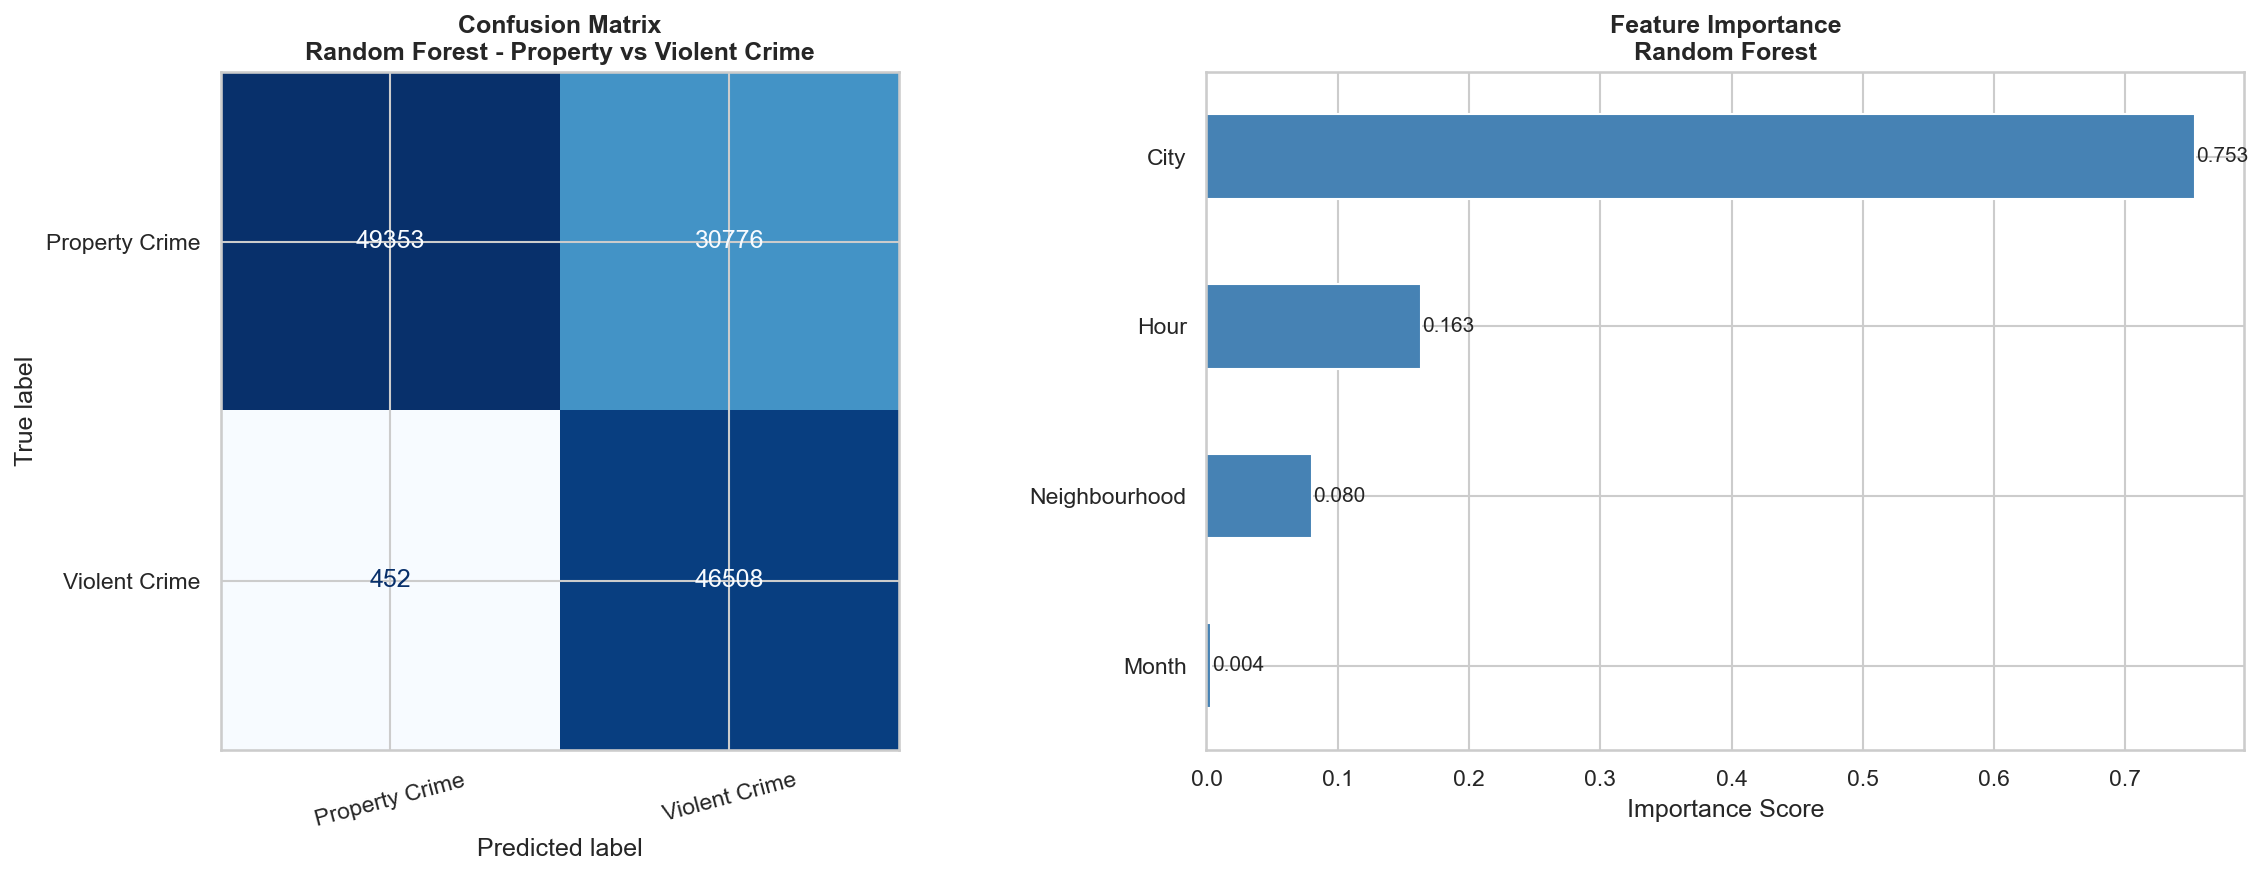

In [57]:
# Confusion Matrix & Feature Importance
fig, axes = plt.subplots(1,2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Confusion Matrix\nRandom Forest - Property vs Violent Crime", fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Feature Importance
feat_imp = pd.Series(rf.feature_importances_,
            index=['City', 'Hour', 'Month', 'Neighbourhood'])
feat_imp = feat_imp.sort_values()
colors = ['#E53935' if v == feat_imp.max() else 'steelblue' for v in feat_imp]
feat_imp.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')

for i, v in enumerate(feat_imp):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=10)
    
axes[1].set_title("Feature Importance\nRandom Forest", fontweight='bold')
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig("../output/figures/model_results.png", dpi = 150, bbox_inches='tight')
plt.show()

In [58]:
# Save model
import joblib
import os

os.makedirs("../output/models", exist_ok=True)

joblib.dump(rf, "../output/models/random_forest.pkl")
joblib.dump(le_city, "../output/models/le_city.pkl")
joblib.dump(le_month, "../output/models/le_month.pkl")
joblib.dump(le_neighbourhood, "../output/models/le_neighbourhood.pkl")
joblib.dump(neighbourhood_features, "../output/models/neighbourhood_clusters.pkl")

# Save neighbourhood clusters
tor_clustered['city'] = 'Toronto'
van_clustered['city'] = 'Vancouver'
clusters = pd.concat([tor_clustered, van_clustered], ignore_index=True)
clusters.to_csv("../output/models/neighbourhood_clusters.csv", index=False)

print("Models saved!")
print(os.listdir("../output/models"))

Models saved!
['le_city.pkl', 'le_month.pkl', 'le_neighbourhood.pkl', 'neighbourhood_clusters.csv', 'neighbourhood_clusters.pkl', 'random_forest.pkl']
